# Restaurant Tipping Analysis
**ShadowFox Python Development Internship — Task 3 (Advanced)**
**Topic:** Jupyter Notebook Data Analysis Project
**Author:** Shaik Sadiya Kousar

## Objective
This notebook explores a dataset of restaurant bills and tips to understand
what factors are associated with how much customers tip. The dataset comes
from a well-known collection used for teaching data analysis (loaded via
`seaborn`'s built-in datasets).

## Research Question
**Does the size of the total bill, the size of the dining party, the day of
the week, or whether the customer smokes have a meaningful relationship with
the tip amount (or tip percentage)?**


## 1. Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Load the tipping dataset
df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 2. Dataset Exploration

Let's understand the shape, data types, and basic statistics of the dataset
before diving into analysis.

In [ ]:
print("Shape of dataset:", df.shape)
print("\nColumn data types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())

Shape of dataset: (244, 7)

Column data types:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Missing values per column:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [ ]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


**Observations:**
- The dataset has 244 rows and 7 columns — no missing values, so no cleaning
  was required.
- `total_bill` and `tip` are continuous numeric variables.
- `sex`, `smoker`, `day`, and `time` are categorical variables.
- `size` represents how many people were in the dining party.

## 3. Feature Engineering

To make comparisons fair across bills of different sizes, we calculate a
**tip percentage** column (`tip / total_bill`). A ₹2 tip on a ₹10 bill is a
much bigger gesture than a ₹2 tip on a ₹100 bill, so raw tip amount alone
can be misleading.

In [ ]:
df["tip_pct"] = (df["tip"] / df["total_bill"]) * 100
df[["total_bill", "tip", "tip_pct"]].head()

,total_bill,tip,tip_pct
0,16.99,1.01,5.944673
1,10.34,1.66,16.054159
2,21.01,3.50,16.658734
3,23.68,3.31,13.978041
4,24.59,3.61,14.680765


## 4. Does a bigger bill mean a bigger tip?

Correlation between total_bill and tip: 0.676


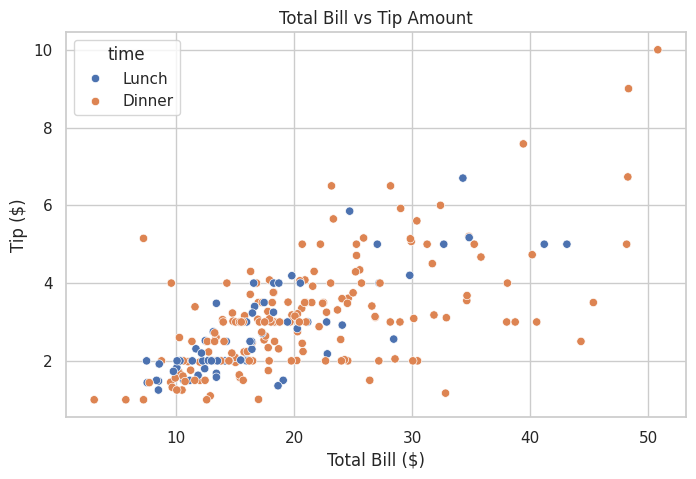

In [ ]:
correlation = df["total_bill"].corr(df["tip"])
print(f"Correlation between total_bill and tip: {correlation:.3f}")

sns.scatterplot(data=df, x="total_bill", y="tip", hue="time")
plt.title("Total Bill vs Tip Amount")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.show()

**Insight:** There is a fairly strong positive correlation (~0.68) between
total bill and tip amount — as expected, people tend to tip more in absolute
dollars when the bill is larger. However, this doesn't necessarily mean they
tip more *generously* — that's what tip percentage helps clarify next.

## 5. Does the day of the week affect tipping generosity?

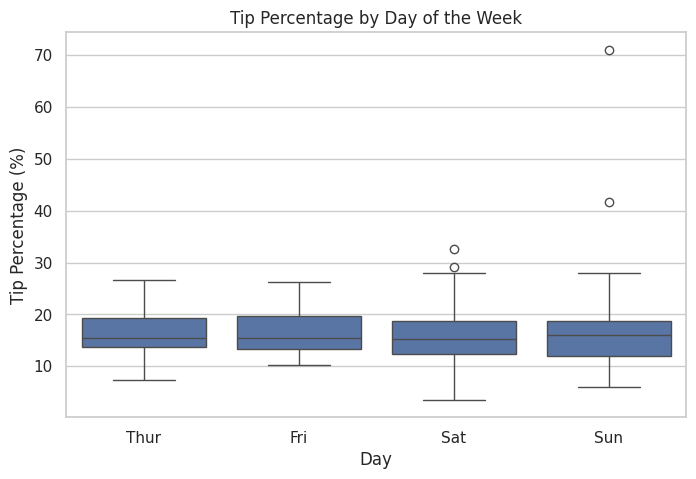

day
Thur    16.127563
Fri     16.991303
Sat     15.315172
Sun     16.689729
Name: tip_pct, dtype: float64

In [ ]:
day_order = ["Thur", "Fri", "Sat", "Sun"]
sns.boxplot(data=df, x="day", y="tip_pct", order=day_order)
plt.title("Tip Percentage by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Tip Percentage (%)")
plt.show()

df.groupby("day", observed=True)["tip_pct"].mean().reindex(day_order)

**Insight:** Average tip percentage is fairly similar across days, though
Friday shows a bit more spread. There isn't a dramatic difference — tipping
generosity doesn't appear to be strongly driven by which day it is.

## 6. Does party size affect tip percentage?

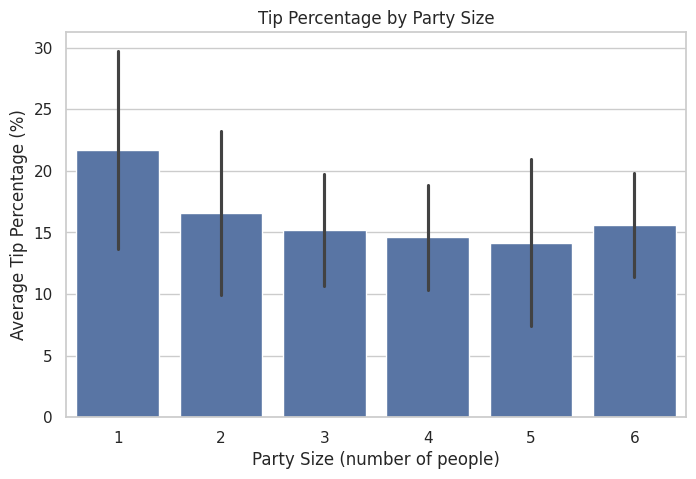

In [ ]:
sns.barplot(data=df, x="size", y="tip_pct", errorbar="sd")
plt.title("Tip Percentage by Party Size")
plt.xlabel("Party Size (number of people)")
plt.ylabel("Average Tip Percentage (%)")
plt.show()

**Insight:** Smaller parties (especially parties of 1-2) tend to leave a
slightly higher tip percentage on average than larger groups. This matches a
pattern often seen in the restaurant industry — larger groups sometimes tip
proportionally less, possibly because the bill is already large.

## 7. Do smokers tip differently than non-smokers?

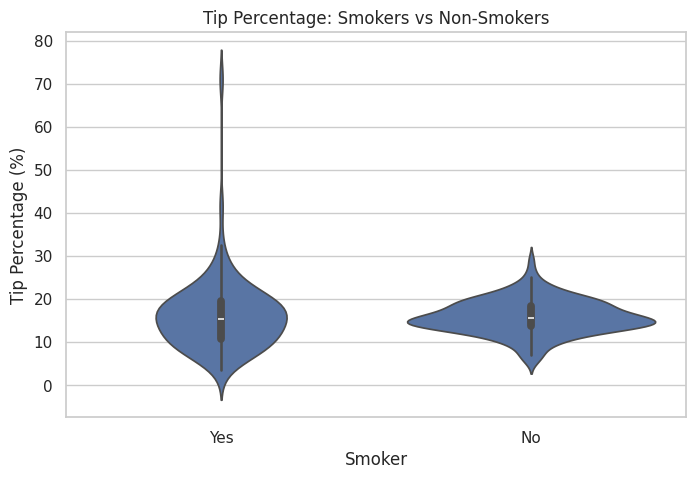

,mean,median,std
smoker,,,
Yes,16.319604,15.384615,8.511920
No,15.932846,15.562472,3.990977


In [ ]:
sns.violinplot(data=df, x="smoker", y="tip_pct")
plt.title("Tip Percentage: Smokers vs Non-Smokers")
plt.xlabel("Smoker")
plt.ylabel("Tip Percentage (%)")
plt.show()

df.groupby("smoker", observed=True)["tip_pct"].agg(["mean", "median", "std"])

**Insight:** Smokers show slightly more variability in tip percentage (a
wider spread, including some very high and very low tippers), while
non-smokers tip a bit more consistently. The average, however, is fairly
close between the two groups.

## 8. Overall Correlation Between Numeric Variables

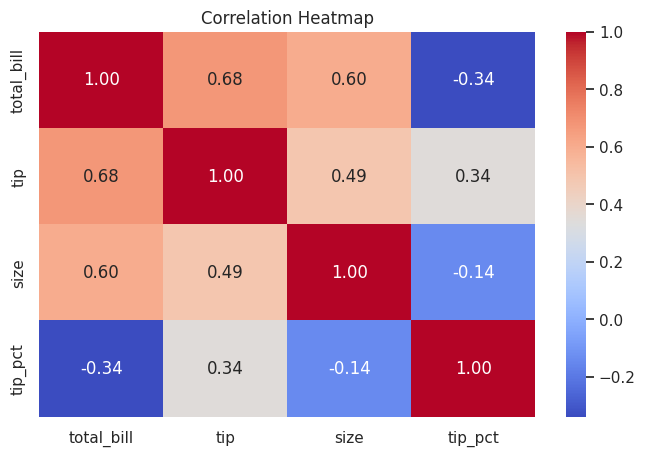

In [ ]:
numeric_cols = df[["total_bill", "tip", "size", "tip_pct"]]
corr_matrix = numeric_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 9. Conclusion and Insights

- **Total bill and tip amount** are strongly positively correlated (~0.68) —
  bigger bills lead to bigger tips in absolute terms.
- **Tip percentage**, a fairer measure of generosity, does not vary
  dramatically by day of the week.
- **Smaller dining parties** tend to leave a slightly higher tip percentage
  than larger groups.
- **Smokers and non-smokers** tip similarly on average, though smokers show
  more variability.

### Potential Applications
A restaurant could use insights like this to understand tipping patterns —
for example, training staff to be aware that very large parties may need
extra attentive service to maintain tip percentage, since group size is
mildly associated with lower tipping generosity.

### Areas for Further Analysis
With a larger dataset, it would be worth testing whether these patterns hold
statistically (e.g., using a t-test between smokers/non-smokers) rather than
relying on visual inspection alone.